In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

In [3]:
# === 1. Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/kaggle/input/speed-limit-classes/Speed_Limit_Class"

In [4]:
# === 2. Transforms ===
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [5]:
# === 3. Load Dataset ===
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
num_classes = len(dataset.classes)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)


In [6]:
# === 4. Define CNN Model ===
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [7]:
# === 5. Loss and Optimizer ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
# === 6. Training Loop ===
num_epochs = 20
best_val_loss = float("inf")
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

Epoch 20/20: 100%|██████████| 27/27 [00:01<00:00, 14.60it/s]


In [10]:
# === 7. Validation ===
model.eval()
val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

epoch_val_loss = val_loss / len(val_loader.dataset)
epoch_val_acc = correct / total
val_losses.append(epoch_val_loss)
val_accuracies.append(epoch_val_acc)

print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2%} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2%}")

# === 8. Save best model ===
if epoch_val_loss < best_val_loss:
    best_val_loss = epoch_val_loss
    torch.save(model.state_dict(), "best_speed_class_cnn.pt")
    print("✅ Best model saved!")


Train Loss: 0.0005 | Train Acc: 100.00% | Val Loss: 0.2446 | Val Acc: 94.39%
✅ Best model saved!


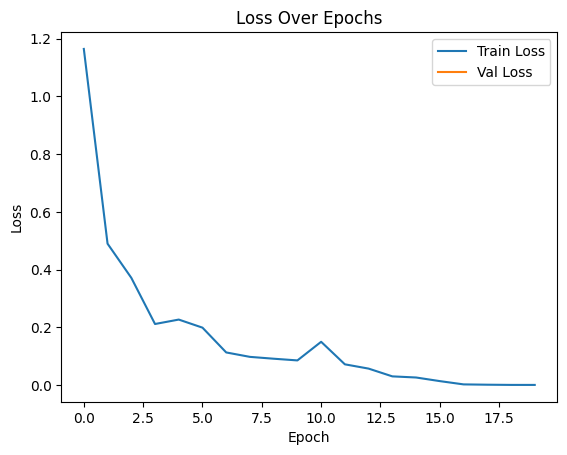

In [11]:
# === 9. Plot Training & Validation Loss ===
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.savefig("/kaggle/working/loss_plot.png")
plt.show()

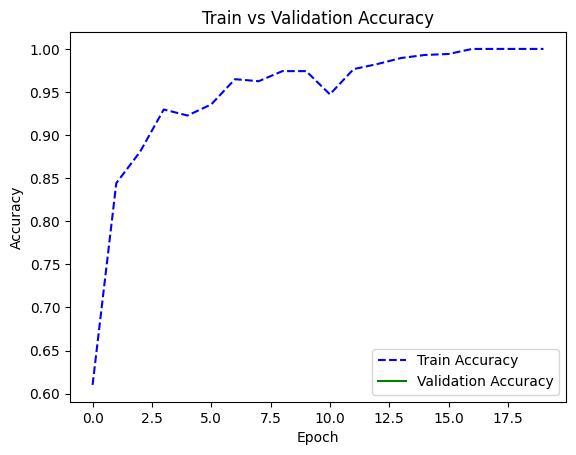

In [12]:
# === 10. Plot Accuracy (Train vs Validation) ===
plt.plot(train_accuracies, label="Train Accuracy", linestyle='--', color='blue')
plt.plot(val_accuracies, label="Validation Accuracy", linestyle='-', color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.savefig("/kaggle/working/train_val_accuracy_plot.png")
plt.show()


📊 Classification Report:
                 precision    recall  f1-score   support

Speed limit 110       1.00      0.67      0.80         3
 Speed limit 20       0.97      0.94      0.96        35
 Speed limit 30       0.75      0.75      0.75        12
 Speed limit 40       1.00      1.00      1.00        14
 Speed limit 50       0.90      0.96      0.93        27
 Speed limit 60       0.71      0.91      0.80        11
 Speed limit 70       1.00      0.96      0.98        25
 Speed limit 80       0.98      0.98      0.98        59
 Speed limit 90       1.00      0.93      0.96        28

       accuracy                           0.94       214
      macro avg       0.92      0.90      0.91       214
   weighted avg       0.95      0.94      0.94       214



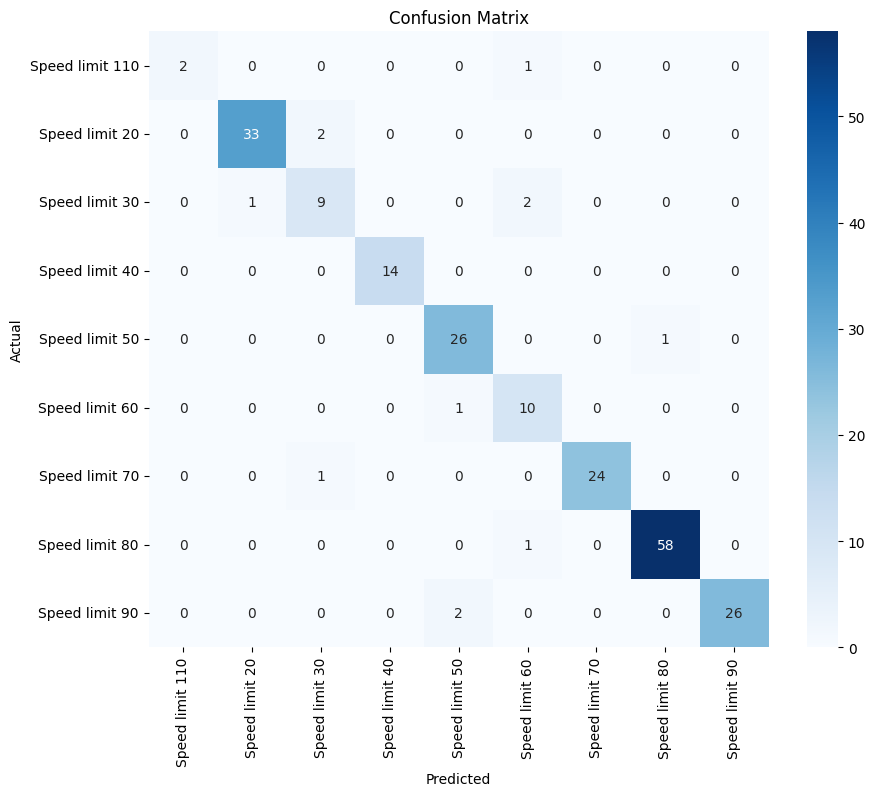

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# === 11. Classification Report & Confusion Matrix ===
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ✅ Get class names from dataset
class_names = dataset.classes

# Report
print("📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()
